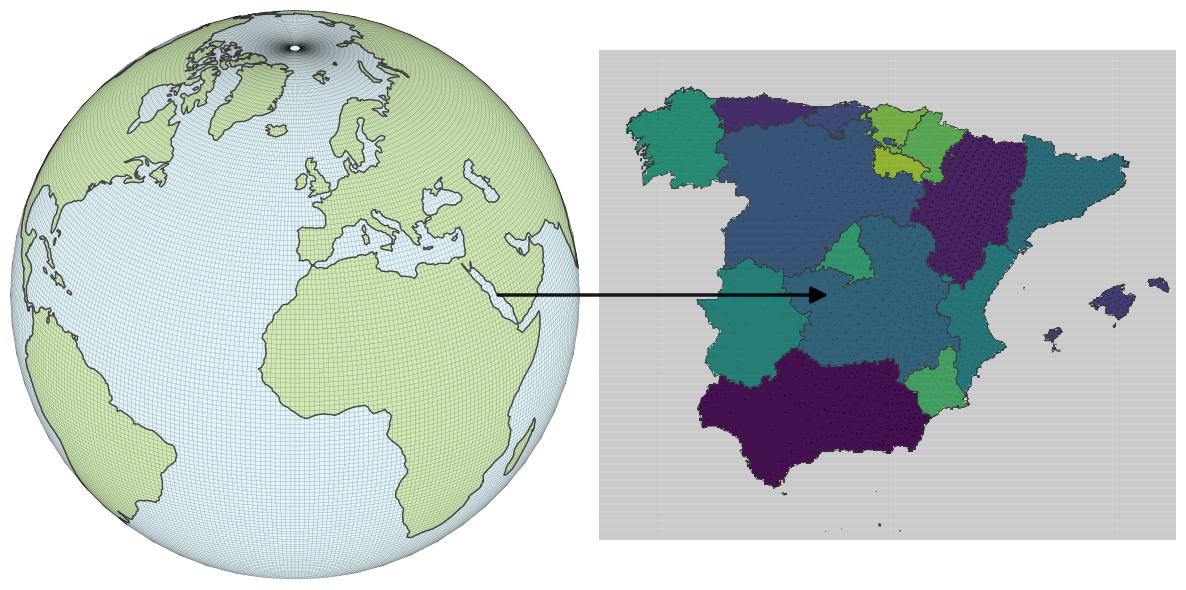

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from matplotlib.patches import Circle, FancyArrowPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# 1. Parámetros y datos
# ============================================================

# Shapefile de Comunidades Autónomas (tu ruta)
shp_path = "/etc/ecmwf/nfs/dh2_perm_b/esp9221/verificacion/recintos_autonomicas_inspire_peninbal_etrs89.shp"
ccaa = gpd.read_file(shp_path)

# Nos aseguramos de que está en lon/lat (EPSG:4326)
if ccaa.crs is not None:
    ccaa = ccaa.to_crs(epsg=4326)

# Extent aproximado para la Península Ibérica
extent_iberia = [-10.0, 4.5, 35.0, 44.5]  # [lon_min, lon_max, lat_min, lat_max]

# ============================================================
# 2. Figura y ejes
# ============================================================

fig = plt.figure(figsize=(12, 6), facecolor="white")

# Globo a la izquierda
proj_globe = ccrs.Orthographic(central_longitude=-10, central_latitude=30)
ax_globe = fig.add_subplot(1, 2, 1, projection=proj_globe)
ax_globe.set_global()

# Lupa / zoom a la derecha
proj_zoom = ccrs.PlateCarree()
ax_zoom = fig.add_subplot(1, 2, 2, projection=proj_zoom)
ax_zoom.set_extent(extent_iberia, crs=proj_zoom)

# Quitamos bordes de los ejes (los pone luego la lupa)


for ax in [ax_globe, ax_zoom]:
    try:
        ax.spines['geo'].set_visible(False)  # Cartopy > 0.21
    except Exception:
        pass
    
    try:
        ax.outline_patch.set_visible(False)  # Cartopy < 0.21
    except Exception:
        pass



# ============================================================
# 3. Globo con grid de 1º
# ============================================================

# Tierra en colores suaves
land = cfeature.NaturalEarthFeature(
    "physical", "land", "110m",
    edgecolor="0.3", facecolor="#cfe8b4"  # verde pastel suave
)
ocean = cfeature.NaturalEarthFeature(
    "physical", "ocean", "110m",
    edgecolor="none", facecolor="#e0f3f8"  # azul muy claro
)

ax_globe.add_feature(ocean, zorder=0)
ax_globe.add_feature(land, zorder=1)

# Costas ligeras
ax_globe.coastlines(resolution="110m", linewidth=0.4, color="0.3", zorder=2)

# Rejilla de 1º (lineas muy finas para que no recargue demasiado)
gl = ax_globe.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.1,
    color="black",
    alpha=0.8
)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 1))
gl.ylocator = plt.FixedLocator(np.arange(-90, 91, 1))



from matplotlib.patches import FancyArrowPatch

# ============================================================
# FLECHA HORIZONTAL MUNDO ➜ IBERIA
# ============================================================

# Coordenadas en el sistema de la figura (0–1)
arrow = FancyArrowPatch(
    posA=(0.42, 0.5),   # parte derecha del globo
    posB=(0.70, 0.5),   # parte izquierda del mapa de Iberia
    arrowstyle='-|>',   # punta moderna
    mutation_scale=25,  # tamaño punta
    linewidth=2.5,
    color="black",
    alpha=0.9,
    transform=fig.transFigure,
    zorder=20
)

fig.add_artist(arrow)



# ============================================================
# 4. Orografía REAL desde tu NetCDF de regionalización
# ============================================================

import xarray as xr
import regionmask
import numpy as np

# ---- Leer el archivo NetCDF (tu regionalización 0.05º)
path_forecast_reg = f'/home/esp2922/hpcperm/s51/forecast/202510/OUTPUTS/ascii_acc/nc'
file_nc = f"pr_IB0.05r_0.05rdeg_forecast.s51.202510_5m.nc"

reg_forecast = xr.open_dataset(path_forecast_reg + "/" + file_nc)

# media en miembros + eliminar time si existe
if "member" in reg_forecast.dims:
    reg_forecast = reg_forecast.mean("member")

if "time" in reg_forecast.dims:
    reg_forecast = reg_forecast.squeeze("time")

# ---- Variable a pintar (selecciona lo que quieras, ej. orografía)
# si tu variable no es orografía, dime cuál quieres usar
var_da = list(reg_forecast.data_vars.values())[0]

# ---- Crear máscara exacta poligonal desde CCAA
ccaa["NATCODE_NUM"] = ccaa["NATCODE"].astype("category").cat.codes


# ---- Selección de variable del NetCDF
var_da = reg_forecast["pr"]

# ---- Añadir lon/lat 2D como coordenadas correctas
var_da = var_da.assign_coords(
    lon=(("rlat", "rlon"), reg_forecast["lon"].values),
    lat=(("rlat", "rlon"), reg_forecast["lat"].values)
)

# ---- Renombrar dims para consistencia
var_da = var_da.rename({"rlat": "y", "rlon": "x"})

# ---- Crear máscara desde shapefile usando NATCODE_NUM
mask = regionmask.from_geopandas(ccaa, numbers="NATCODE_NUM")

# ---- Aplicar máscara
var_masked = mask.mask(var_da)
var_masked = var_masked.where(~np.isnan(var_masked))






# ---- Pintar con colormap pastel dentro del eje zoom
im = ax_zoom.pcolormesh(
    var_masked.lon,
    var_masked.lat,
    var_masked,
    shading="auto",
    alpha=0.9,
    zorder=1,
    transform=proj_zoom
)

# ---- Contorno de las CCAA
ccaa.boundary.plot(
    ax=ax_zoom,
    transform=proj_zoom,
    linewidth=0.5,
    color="0.3",
    zorder=3
)


#  Rejilla de 0.05º sobre Iberia

lon_lines = np.arange(extent_iberia[0], extent_iberia[1] + 0.001, 0.05)
lat_lines = np.arange(extent_iberia[2], extent_iberia[3] + 0.001, 0.005)

# Líneas muy claras para que se vea "alta resolución"
for lo in lon_lines:
    ax_zoom.plot(
        [lo, lo],
        [extent_iberia[2], extent_iberia[3]],
        transform=proj_zoom,
        color="black",
        linewidth=0.05,
        alpha=0.7,
        zorder=4)

for la in lat_lines:
    ax_zoom.plot(
        [extent_iberia[0], extent_iberia[1]],
        [la, la],
        transform=proj_zoom,
        color="black",
        linewidth=0.05,
        alpha=0.7,
        zorder=4)

# Quitamos ticks
ax_zoom.set_xticks([])
ax_zoom.set_yticks([])


plt.tight_layout()
plt.savefig("downscaling_iberia.png", dpi=300, bbox_inches="tight")
plt.show()
